# CESNET-TimeSeries24 — Preprocessing Pipeline

**Mục tiêu:** Chuyển đổi dữ liệu thô → tensor-ready format cho model forecasting mask-aware.

## Các bước chính
1. Load time spine, calendar, hierarchy metadata
2. Mask-aware loading (observed_mask thay vì zero-fill)
3. Log1p transform + per-entity RobustScaler
4. Calendar & gap features
5. Train/Val/Test split (14/2/24 weeks — benchmark protocol)
6. Flag outage window (sensor failure May–June 2024)
7. Save to Parquet + pickle scalers

## Tài liệu tham khảo
- **Dataset paper:** https://www.nature.com/articles/s41597-025-04603-x (Scientific Data 2025)
- **Benchmark:** arXiv:2503.17410 — *Comparative Analysis of DL Models for Real-World ISP Network Traffic Forecasting*
- **EDA:** `eda-report.md` (rigorous EDA, 8 bước, 6718 hourly slots)
- **Official example:** `references/CESNET-TimeSeries24-Example/example.ipynb`

## Lý do thiết kế quan trọng (từ EDA)
| Phát hiện EDA | Quyết định tiền xử lý |
|---|---|
| `n_bytes` cực heavy-tailed (skew=12, kurtosis=303) | Log1p transform bắt buộc |
| Missing = telemetry absence, không phải zero traffic | `observed_mask` thay cho zero-fill |
| ACF peaks mạnh tại lag-24h, lag-168h | Calendar features: sin/cos hour, dow |
| Gaps > 24h phá vỡ seasonality | `gap_since_last_obs` feature |
| Outage window May 20 – Jun 10, 2024 | Flag `is_outage` cho robustness eval |
| Parent ≈ sum(children) < 0.015% error | Giữ hierarchy keys cho reconciliation |

In [29]:
# Uncomment nếu chưa cài:
# !pip install pandas numpy scikit-learn matplotlib seaborn pyarrow tqdm

In [30]:
import os, sys, warnings, json, pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)
np.random.seed(42)

print(f"pandas {pd.__version__}, numpy {np.__version__}")

pandas 2.2.3, numpy 1.26.4


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────
DATA_ROOT = Path(r"D:/Paper/CESNET-TimeSeries24/data")
OUT_ROOT  = Path(r"D:/Paper/CESNET-TimeSeries24/preprocessed")
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

# ── Aggregation level ──────────────────────────────────────────────
AGG          = "agg_1_hour"
TOTAL_SLOTS  = 6718

# ── Known data issues ─────────────────────────────────────────────
# Subnets 18 and 235: present in identifiers.csv but have NO hourly/daily files
# (only agg_10_minutes available). Excluded from all panels.
EXCLUDED_SUBNETS = [18, 235]

# Subnets with IPs belonging to 2 parent institutions → merge must pick primary
# (institution with most IPs). Failure to do so duplicates 4×6718=26,872 rows.
# subnet 264: inst 69(124 IPs) vs 279(1)  → primary=69
# subnet 281: inst 81(9)  vs 121(8)       → primary=81
# subnet 345: inst 123(24) vs 143(8)      → primary=123
# subnet 359: inst 134(2)  vs 280(2)      → primary=134 (tie → lower ID)
MULTI_PARENT_SUBNETS = [264, 281, 345, 359]

# ── Hierarchy levels metadata ──────────────────────────────────────
LEVELS = {
    "institutions": {
        "id_col": "id_institution",
        "n_entities": 283,
        "missing_rate_mean": 0.0111,
        "missing_rate_median": 0.0001489,
    },
    "institution_subnets": {
        "id_col": "id_institution_subnet",
        "n_entities": 546,        # 548 in identifiers.csv − 2 excluded (no hourly file)
        "missing_rate_mean": 0.0382,
        "missing_rate_median": 0.0001489,
    },
    "ip_addresses_sample": {
        "id_col": "id_ip",
        "n_entities": 1000,
        "missing_rate_mean": 0.7903,
        "missing_rate_median": 0.9256,
    },
}

# ── Train/Val/Test split ────────────────────────────────────────────
TRAIN_WEEKS = 14
VAL_WEEKS   = 2
TRAIN_END   = TRAIN_WEEKS * 168   # id_time 2352
VAL_END     = TRAIN_END + VAL_WEEKS * 168  # id_time 2688

# ── Outage window ──────────────────────────────────────────────────
OUTAGE_START_DT = pd.Timestamp("2024-05-20 00:00:00+00:00")
OUTAGE_END_DT   = pd.Timestamp("2024-06-10 23:00:00+00:00")

# ── Features ────────────────────────────────────────────────────────
TARGET      = "n_bytes"
COUNT_COLS  = ["n_flows", "n_packets", "n_bytes",
               "sum_n_dest_asn", "sum_n_dest_ports", "sum_n_dest_ip"]
RATIO_COLS  = ["tcp_udp_ratio_packets", "tcp_udp_ratio_bytes",
               "dir_ratio_packets", "dir_ratio_bytes"]
FEATURE_COLS = ["n_flows", "n_packets",
                "tcp_udp_ratio_bytes", "dir_ratio_bytes",
                "avg_duration", "avg_ttl"]
RATIO_FILL  = 0.5
COUNT_FILL  = np.nan

# ── Leakage classification (for DataLoader notebook) ──────────────
# EVAL_ONLY: filtering/evaluation only — NEVER pass as model input feature
EVAL_ONLY_COLS     = ["split", "is_outage"]
# PAST_ENCODER_ONLY: safe for encoder (past context) and loss mask,
#                    but MUST NOT be given as future/decoder inputs
PAST_ENCODER_COLS  = ["observed_mask", "gap_since_last_obs", "gap_bucket", "is_gap_start"]
# KNOWN_FUTURE: available at forecast time (calendar) — safe as decoder inputs
KNOWN_FUTURE_COLS  = ["sin_hour", "cos_hour", "sin_dow", "cos_dow",
                       "is_weekend", "is_holiday", "hour", "day_of_week",
                       "month", "week_of_year"]
# time_idx_norm: technically known future but normalised over full horizon →
# slightly leaky for variable-length contexts; prefer calendar features instead
CAUTION_COLS       = ["time_idx_norm"]

print(f"Train slots : {TRAIN_END:,}  ({TRAIN_WEEKS} weeks)")
print(f"Val slots   : {VAL_END - TRAIN_END:,}  ({VAL_WEEKS} weeks)")
print(f"Test slots  : {TOTAL_SLOTS - VAL_END:,}  (~{(TOTAL_SLOTS-VAL_END)//168} weeks)")
print(f"Excluded subnets: {EXCLUDED_SUBNETS}  (no hourly file)")
print(f"Multi-parent subnets: {MULTI_PARENT_SUBNETS}  (primary institution used)")

## 1. Load Skeleton Data

Load time spine (`times_1_hour.csv`), calendar markers, và hierarchy relationship map.
Đây là 3 file metadata không phụ thuộc entity, dùng chung cho tất cả levels.

In [32]:
# ── Time spine ─────────────────────────────────────────────────────
df_times = pd.read_csv(DATA_ROOT / "times" / "times_1_hour.csv")
df_times["time"] = pd.to_datetime(df_times["time"])

assert len(df_times) == TOTAL_SLOTS, f"Expected {TOTAL_SLOTS} slots, got {len(df_times)}"
print(f"Time spine : {df_times['time'].min()} → {df_times['time'].max()}")
print(f"  Slots    : {len(df_times):,}")
print(f"  Step     : {(df_times['time'].iloc[1] - df_times['time'].iloc[0])}")

# ── Weekends & holidays ────────────────────────────────────────────
df_cal = pd.read_csv(DATA_ROOT / "weekends_and_holidays.csv")
df_cal["Date"] = pd.to_datetime(df_cal["Date"]).dt.date
holiday_dates  = set(df_cal.loc[df_cal["Type"] != "Weekend", "Date"])
print(f"\nCalendar   : {len(df_cal)} entries, {len(holiday_dates)} unique holidays")

# ── Hierarchy relationship map ─────────────────────────────────────
df_ids_rel = pd.read_csv(DATA_ROOT / "ids_relationship.csv")
print(f"\nIDs rel    : {len(df_ids_rel):,} rows")
print(f"  Columns  : {list(df_ids_rel.columns)}")
df_ids_rel.head(3)

Time spine : 2023-10-09 00:00:00+00:00 → 2024-07-14 21:00:00+00:00
  Slots    : 6,718
  Step     : 0 days 01:00:00

Calendar   : 91 entries, 9 unique holidays

IDs rel    : 275,124 rows
  Columns  : ['id_ip', 'id_institution', 'id_institution_subnet']


,id_ip,id_institution,id_institution_subnet
0,42,0,0
1,52,0,0
2,275,0,0


In [33]:
# ── Compute outage window id_time bounds ───────────────────────────
OUTAGE_START_ID = int(df_times.loc[df_times["time"] >= OUTAGE_START_DT, "id_time"].iloc[0])
OUTAGE_END_ID   = int(df_times.loc[df_times["time"] <= OUTAGE_END_DT,   "id_time"].iloc[-1])

t_start = df_times.loc[df_times["id_time"]==OUTAGE_START_ID, "time"].values[0]
t_end   = df_times.loc[df_times["id_time"]==OUTAGE_END_ID,   "time"].values[0]
n_slots = OUTAGE_END_ID - OUTAGE_START_ID + 1

print(f"Outage window: id_time {OUTAGE_START_ID} → {OUTAGE_END_ID}")
print(f"  Timestamps : {t_start} → {t_end}")
print(f"  Duration   : {n_slots} slots ({n_slots/24:.1f} days)")
print(f"  In test set: {OUTAGE_START_ID >= VAL_END} (test starts at id_time {VAL_END})")

Outage window: id_time 5376 → 5903
  Timestamps : 2024-05-20T00:00:00.000000000 → 2024-06-10T23:00:00.000000000
  Duration   : 528 slots (22.0 days)
  In test set: True (test starts at id_time 2688)


## 2. Mask-Aware Data Loading

**Tại sao KHÔNG dùng zero-fill cho target?**

EDA Step 1 xác nhận: missing rows = telemetry absence (probe không ghi được), **không phải** zero traffic thực sự. Benchmark CESNET 2025 (arXiv:2503.17410) dùng zero-fill và thấy missingness làm giảm R² đáng kể ở IP-level. Paper dataset chính thức yêu cầu scaler, loss, validation metric phải mask-aware.

Giải pháp: **left-join** mỗi entity CSV lên time spine đầy đủ → tạo cột `observed_mask` (1=có dữ liệu, 0=missing). Ratio columns điền 0.5 (neutral), count/target columns giữ NaN.

In [34]:
def load_entity_series(csv_path: Path) -> pd.DataFrame:
    """Load one entity CSV, left-join to full time spine, create observed_mask.

    Returns DataFrame with TOTAL_SLOTS rows.
    observed_mask=1 for real observations, 0 for missing (telemetry gap).
    """
    df = pd.read_csv(csv_path)

    # Left join: all 6718 time slots, unobserved rows → NaN
    df_full = df_times[["id_time", "time"]].merge(df, on="id_time", how="left")

    # Mark observed rows (any count col being non-null is sufficient)
    df_full["observed_mask"] = df_full[TARGET].notna().astype(np.int8)

    # Neutral fill for ratio columns (bounded [0,1]; 0.5 = no TCP/UDP preference)
    for col in RATIO_COLS:
        if col in df_full.columns:
            df_full[col] = df_full[col].fillna(RATIO_FILL).astype(np.float32)

    # avg_duration and avg_ttl: fill with 0 for unobserved (not used in target loss)
    for col in ["avg_duration", "avg_ttl"]:
        if col in df_full.columns:
            df_full[col] = df_full[col].fillna(0.0).astype(np.float32)

    return df_full


def load_level(level: str, agg: str = AGG, verbose: bool = True) -> dict:
    """Load all entity CSVs for a hierarchy level.

    Returns dict: entity_id (int) → DataFrame (TOTAL_SLOTS rows, with observed_mask).
    """
    id_col  = LEVELS[level]["id_col"]
    id_file = DATA_ROOT / level / "identifiers.csv"
    level_dir = DATA_ROOT / level / agg

    identifiers = pd.read_csv(id_file)
    entity_ids  = identifiers[id_col].tolist()

    result = {}
    missing_files = []
    for eid in tqdm(entity_ids, desc=f"Loading {level}", disable=not verbose):
        csv_path = level_dir / f"{eid}.csv"
        if csv_path.exists():
            result[eid] = load_entity_series(csv_path)
        else:
            missing_files.append(eid)

    n_loaded = len(result)
    if missing_files:
        print(f"  WARNING: {len(missing_files)} CSV files not found: {missing_files[:5]}...")
    print(f"Loaded {n_loaded}/{len(entity_ids)} entities for '{level}'")
    return result

## 3. Load Datasets

Theo khuyến nghị từ `deep-research-report.md`:
- **Primary track:** `institutions / agg_1_hour` (283 series, stable, ~1.2 GB)
- **Secondary track:** `institution_subnets / agg_1_hour` (546 series, ~2 GB)
- **Sparsity stress test:** `ip_addresses_sample / agg_1_hour` (1000 series, missing 79%)

In [35]:
data_institutions = load_level("institutions")

Loading institutions:   0%|          | 0/283 [00:00<?, ?it/s]

Loaded 283/283 entities for 'institutions'


In [36]:
data_subnets = load_level("institution_subnets")

Loading institution_subnets:   0%|          | 0/548 [00:00<?, ?it/s]

Loaded 546/548 entities for 'institution_subnets'


In [37]:
data_ips = load_level("ip_addresses_sample")

Loading ip_addresses_sample:   0%|          | 0/1000 [00:00<?, ?it/s]

Loaded 1000/1000 entities for 'ip_addresses_sample'


In [38]:
def validate_loaded(data: dict, level: str):
    """Cross-check missing rates against EDA report values."""
    miss_rates = np.array([1 - df["observed_mask"].mean() for df in data.values()])
    ref_mean   = LEVELS[level]["missing_rate_mean"]
    delta      = abs(miss_rates.mean() - ref_mean)
    status     = "OK" if delta < 0.01 else "CHECK"

    print(f"\n{'─'*50}")
    print(f"Level: {level}")
    print(f"  Entities : {len(data)}")
    print(f"  Missing rate — mean={miss_rates.mean():.4f}  "
          f"median={np.median(miss_rates):.4f}  max={miss_rates.max():.4f}")
    print(f"  EDA ref  : mean={ref_mean:.4f}  delta={delta:.4f}  [{status}]")

    # Quick shape check
    shapes = [df.shape for df in data.values()]
    rows_set = set(s[0] for s in shapes)
    print(f"  Rows/entity: {rows_set}  (expected: {{{TOTAL_SLOTS}}})")

validate_loaded(data_institutions, "institutions")
validate_loaded(data_subnets,      "institution_subnets")
validate_loaded(data_ips,          "ip_addresses_sample")


──────────────────────────────────────────────────
Level: institutions
  Entities : 283
  Missing rate — mean=0.0111  median=0.0001  max=0.8657
  EDA ref  : mean=0.0111  delta=0.0000  [OK]
  Rows/entity: {6718}  (expected: {6718})

──────────────────────────────────────────────────
Level: institution_subnets
  Entities : 546
  Missing rate — mean=0.0382  median=0.0001  max=0.9355
  EDA ref  : mean=0.0382  delta=0.0000  [OK]
  Rows/entity: {6718}  (expected: {6718})

──────────────────────────────────────────────────
Level: ip_addresses_sample
  Entities : 1000
  Missing rate — mean=0.7903  median=0.9256  max=0.9997
  EDA ref  : mean=0.7903  delta=0.0000  [OK]
  Rows/entity: {6718}  (expected: {6718})


## 4. Calendar Feature Engineering

EDA Step 4 (ACF/FFT) xác nhận:
- **Lag-24h ACF = 0.68** → mạnh, cần encode hour-of-day
- **Lag-168h ACF = 0.58** → rõ rệt, cần encode day-of-week
- STL seasonality strength trung bình: 24h=0.67, 168h=0.65 → calendar features quan trọng

**Sin/cos encoding** giúp model hiểu tính tuần hoàn (hour 23 gần hour 0) thay vì treat như biến rời rạc.

In [39]:
tf = df_times.copy()
t  = tf["time"]

# ── Categorical time features ──────────────────────────────────────
tf["hour"]        = t.dt.hour.astype(np.int8)
tf["day_of_week"] = t.dt.dayofweek.astype(np.int8)   # 0=Mon, 6=Sun
tf["month"]       = t.dt.month.astype(np.int8)
tf["week_of_year"] = t.dt.isocalendar().week.astype(np.int16)

# ── Cyclic sin/cos (preserves distance between boundary values) ────
tf["sin_hour"] = np.sin(2 * np.pi * tf["hour"] / 24).astype(np.float32)
tf["cos_hour"] = np.cos(2 * np.pi * tf["hour"] / 24).astype(np.float32)
tf["sin_dow"]  = np.sin(2 * np.pi * tf["day_of_week"] / 7).astype(np.float32)
tf["cos_dow"]  = np.cos(2 * np.pi * tf["day_of_week"] / 7).astype(np.float32)

# ── Binary flags ───────────────────────────────────────────────────
tf["is_weekend"] = (tf["day_of_week"] >= 5).astype(np.int8)
tf["is_holiday"] = t.dt.date.apply(lambda d: int(d in holiday_dates)).astype(np.int8)

# ── Trend covariate (normalized time index, useful for drift-aware models) ─
tf["time_idx_norm"] = (tf["id_time"] / (TOTAL_SLOTS - 1)).astype(np.float32)

# ── Split & outage labels ──────────────────────────────────────────
tf["split"] = pd.cut(
    tf["id_time"],
    bins=[-1, TRAIN_END - 1, VAL_END - 1, TOTAL_SLOTS],
    labels=["train", "val", "test"]
)
tf["is_outage"] = (
    (tf["id_time"] >= OUTAGE_START_ID) &
    (tf["id_time"] <= OUTAGE_END_ID)
).astype(np.int8)

TIME_FEATURE_COLS = [
    "id_time", "time",
    "hour", "day_of_week", "month", "week_of_year",
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "is_weekend", "is_holiday",
    "time_idx_norm",
    "split", "is_outage",
]
time_features_df = tf[TIME_FEATURE_COLS].copy()

print(f"time_features_df: {time_features_df.shape}")
print(f"  is_weekend slots : {tf.is_weekend.sum():,}")
print(f"  is_holiday slots : {tf.is_holiday.sum():,}")
print(f"  is_outage slots  : {tf.is_outage.sum():,}")
time_features_df.head(3)

time_features_df: (6718, 15)
  is_weekend slots : 1,918
  is_holiday slots : 216
  is_outage slots  : 528


,id_time,time,hour,day_of_week,month,week_of_year,sin_hour,cos_hour,sin_dow,cos_dow,is_weekend,is_holiday,time_idx_norm,split,is_outage
0,0,2023-10-09 00:00:00+00:00,0,0,10,41,0.000000,1.000000,0.000000,1.000000,0,0,0.000000,train,0
1,1,2023-10-09 01:00:00+00:00,1,0,10,41,0.258819,0.965926,0.000000,1.000000,0,0,0.000149,train,0
2,2,2023-10-09 02:00:00+00:00,2,0,10,41,0.500000,0.866025,0.000000,1.000000,0,0,0.000298,train,0


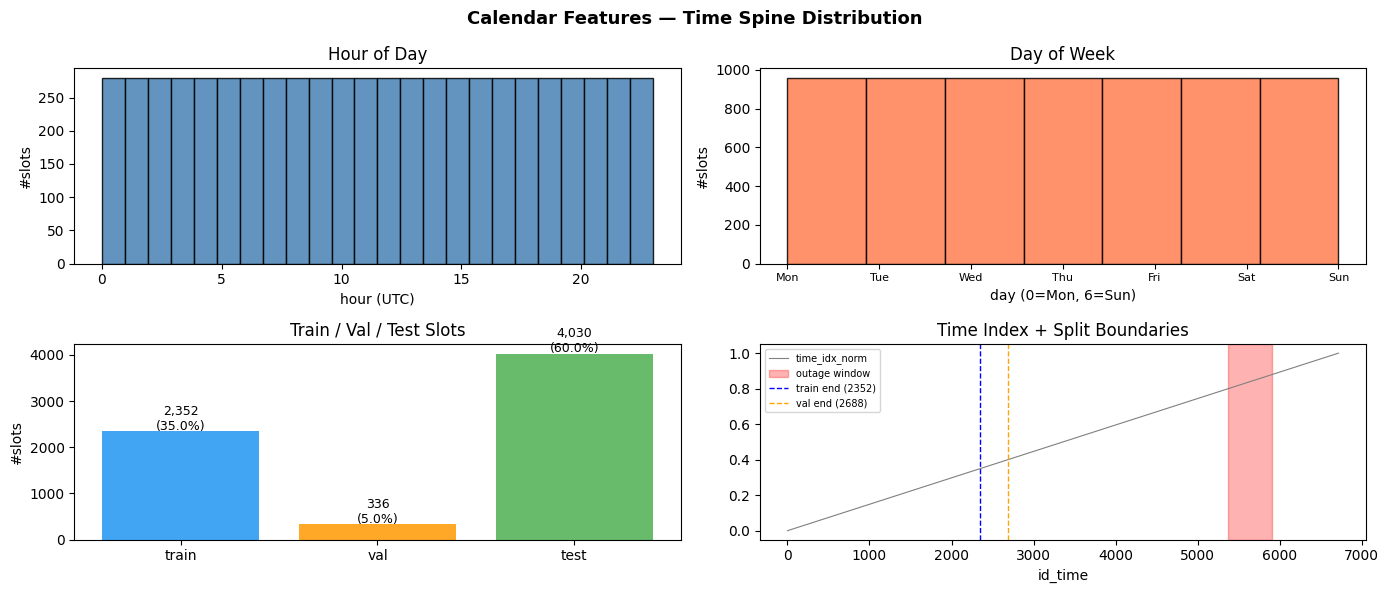

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle("Calendar Features — Time Spine Distribution", fontsize=13, fontweight="bold")

axes[0,0].hist(time_features_df["hour"], bins=24, edgecolor="k", color="steelblue", alpha=0.85)
axes[0,0].set(title="Hour of Day", xlabel="hour (UTC)", ylabel="#slots")

axes[0,1].hist(time_features_df["day_of_week"], bins=7, edgecolor="k", color="coral", alpha=0.85)
axes[0,1].set(title="Day of Week", xlabel="day (0=Mon, 6=Sun)", ylabel="#slots")
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], fontsize=8)

split_counts = time_features_df["split"].value_counts()[["train","val","test"]]
bars = axes[1,0].bar(split_counts.index, split_counts.values,
                     color=["#2196F3","#FF9800","#4CAF50"], alpha=0.85)
axes[1,0].set(title="Train / Val / Test Slots", ylabel="#slots")
for bar, (k, v) in zip(bars, split_counts.items()):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                   f"{v:,}\n({v/TOTAL_SLOTS:.1%})", ha="center", fontsize=9)

# Outage window highlighted on time axis
axes[1,1].plot(time_features_df["id_time"], time_features_df["time_idx_norm"],
               color="gray", lw=0.8, label="time_idx_norm")
axes[1,1].axvspan(OUTAGE_START_ID, OUTAGE_END_ID, alpha=0.3, color="red", label="outage window")
axes[1,1].axvline(TRAIN_END, color="blue", ls="--", lw=1, label=f"train end ({TRAIN_END})")
axes[1,1].axvline(VAL_END,   color="orange", ls="--", lw=1, label=f"val end ({VAL_END})")
axes[1,1].set(title="Time Index + Split Boundaries", xlabel="id_time")
axes[1,1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 5. Gap Feature Engineering

EDA Step 2 (gap bucket analysis):
- Institutions: 62% gaps are 1h, 31% are 2-6h, 0.4% are >168h
- IP-level: 25% are 25-168h, 2.6% are >168h

**`gap_since_last_obs`** giúp model phân biệt:
- Gap 1-6h → có thể interpolate
- Gap 7-24h → phá seasonality ngắn
- Gap >168h → phá seasonality tuần, nên exclude khỏi loss

In [41]:
def compute_gap_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute gap-aware features per entity series.

    gap_since_last_obs: hours since last observed slot (0 if observed, NaN before first obs).
    is_gap_start      : 1 at first missing slot after an observed slot (gap onset marker).
    gap_bucket        : categorical bucket for gap length (1h / 2-6h / 7-24h / 25-168h / >168h).
    """
    mask = df["observed_mask"].values.astype(int)
    n    = len(mask)

    gap_since = np.full(n, np.nan, dtype=np.float32)
    last_obs  = -1
    for i in range(n):
        if mask[i] == 1:
            last_obs     = i
            gap_since[i] = 0.0
        elif last_obs >= 0:
            gap_since[i] = float(i - last_obs)

    shifted_mask = np.roll(mask, 1)
    shifted_mask[0] = 1   # treat first slot as "after observed" to avoid gap_start
    is_gap_start = ((mask == 0) & (shifted_mask == 1)).astype(np.int8)

    df = df.copy()
    df["gap_since_last_obs"] = gap_since
    df["is_gap_start"]       = is_gap_start

    # Categorical gap bucket (NaN for observed rows)
    def _bucket(h):
        if np.isnan(h) or h == 0:
            return "observed"
        if h == 1:   return "1h"
        if h <= 6:   return "2-6h"
        if h <= 24:  return "7-24h"
        if h <= 168: return "25-168h"
        return ">168h"

    df["gap_bucket"] = pd.Categorical(
        [_bucket(h) for h in gap_since],
        categories=["observed","1h","2-6h","7-24h","25-168h",">168h"],
        ordered=True
    )
    return df


# Demo on one institution to verify
demo_id  = list(data_institutions.keys())[0]
demo_df  = compute_gap_features(data_institutions[demo_id])
gap_dist = demo_df["gap_bucket"].value_counts().sort_index()
print(f"Gap bucket distribution — institution {demo_id}:")
print(gap_dist.to_string())

Gap bucket distribution — institution 0:
gap_bucket
observed    6717
1h             1
2-6h           0
7-24h          0
25-168h        0
>168h          0


## 6. Log1p Transform & Per-Entity RobustScaler

EDA Step 3 key findings:
| Level | Raw skew | Log1p skew | IQR outlier share (raw→log1p) |
|---|---|---|---|
| institutions | 11.9 | **-0.81** | 14.3% → 3.8% |
| institution_subnets | 16.5 | -0.31 | 15.9% → **0%** |
| ip_addresses_sample | 16.8 | 0.92 | 19.0% → 2.9% |

**Per-entity RobustScaler** (median/IQR) vì:
1. Entities khác nhau về scale cực lớn (p99_to_p50 ratio = 536 ở institution level)
2. Robust hơn StandardScaler khi còn outliers sau log1p
3. Fit CHỈ trên train split để tránh data leakage

In [42]:
def apply_log1p_transforms(df: pd.DataFrame) -> pd.DataFrame:
    """Apply log1p to count columns; preserve NaN mask for target."""
    df = df.copy()
    for col in COUNT_COLS:
        if col not in df.columns:
            continue
        log_col = f"{col}_log1p"
        vals = df[col].fillna(0.0)
        df[log_col] = np.log1p(vals).astype(np.float32)

    # Target: unobserved rows → NaN in log1p col (mask-aware loss)
    target_log_col = f"{TARGET}_log1p"
    df.loc[df["observed_mask"] == 0, target_log_col] = np.nan
    return df


def fit_entity_scalers(data: dict, min_train_obs: int = 24) -> dict:
    """Fit one RobustScaler per entity on train-split observed log1p(n_bytes).

    Sparse entities (< min_train_obs train observations) fall back to a global
    scaler fit on ALL train observations pooled across all entities — never
    touching val/test. Eliminates data leakage for IP-level series where many
    entities have very few training points (missing_rate_mean=0.79).

    Returns dict: entity_id → fitted RobustScaler.
    """
    target_log = f"{TARGET}_log1p"

    # ── Pass 1: collect train-split obs per entity & build global pool ──────
    all_train_vals   = []
    entity_train_obs = {}
    for eid, df in data.items():
        df_t      = apply_log1p_transforms(df)
        train_obs = df_t.loc[
            (df_t["id_time"] < TRAIN_END) & (df_t["observed_mask"] == 1),
            target_log
        ].dropna()
        entity_train_obs[eid] = train_obs
        all_train_vals.append(train_obs.values)

    # Global scaler: pooled train data only — no leakage
    all_train_arr = np.concatenate(all_train_vals) if all_train_vals else np.array([0.0])
    global_scaler = RobustScaler()
    global_scaler.fit(all_train_arr.reshape(-1, 1))

    n_sparse = sum(1 for obs in entity_train_obs.values() if len(obs) < min_train_obs)
    print(f"  Global scaler : fit on {len(all_train_arr):,} pooled train observations")
    print(f"  Sparse entities (< {min_train_obs} train obs): {n_sparse}/{len(data)}"
          f"  → use global fallback")

    # ── Pass 2: per-entity scaler; global for sparse entities ───────────────
    scalers = {}
    for eid in tqdm(entity_train_obs, desc="Fitting per-entity scalers", leave=False):
        train_obs = entity_train_obs[eid]
        if len(train_obs) >= min_train_obs:
            scaler = RobustScaler()
            scaler.fit(train_obs.values.reshape(-1, 1))
        else:
            scaler = global_scaler  # shared read-only reference — no leakage
        scalers[eid] = scaler
    return scalers


def apply_entity_scaler(df: pd.DataFrame, scaler: RobustScaler) -> pd.DataFrame:
    """Apply fitted scaler to log1p(n_bytes) → n_bytes_scaled.

    Unobserved rows remain NaN in n_bytes_scaled.
    """
    target_log = f"{TARGET}_log1p"
    scaled_col = f"{TARGET}_scaled"
    df = df.copy()

    obs_mask    = df["observed_mask"].values == 1
    scaled_vals = np.full(len(df), np.nan, dtype=np.float32)

    if obs_mask.sum() > 0:
        vals = df.loc[obs_mask, target_log].values.reshape(-1, 1)
        scaled_vals[obs_mask] = scaler.transform(vals).ravel()

    df[scaled_col] = scaled_vals
    return df

In [43]:
print("Fitting scalers...")
scalers_inst = fit_entity_scalers(data_institutions)
scalers_sub  = fit_entity_scalers(data_subnets)
scalers_ips  = fit_entity_scalers(data_ips)
print(f"Scalers fitted: inst={len(scalers_inst)}, sub={len(scalers_sub)}, ip={len(scalers_ips)}")

Fitting scalers...
  Global scaler : fit on 658,393 pooled train observations
  Sparse entities (< 24 train obs): 0/283  → use global fallback


Fitting per-entity scalers:   0%|          | 0/283 [00:00<?, ?it/s]

  Global scaler : fit on 1,225,982 pooled train observations
  Sparse entities (< 24 train obs): 6/546  → use global fallback


Fitting per-entity scalers:   0%|          | 0/546 [00:00<?, ?it/s]

  Global scaler : fit on 524,323 pooled train observations
  Sparse entities (< 24 train obs): 368/1000  → use global fallback


Fitting per-entity scalers:   0%|          | 0/1000 [00:00<?, ?it/s]

Scalers fitted: inst=283, sub=546, ip=1000


In [44]:
# Verify skew reduction on sample institutions (EDA ref: raw~12, log1p~-0.8)
sample_ids = list(data_institutions.keys())[:8]
rows = []
for eid in sample_ids:
    df_t = apply_log1p_transforms(data_institutions[eid])
    obs  = df_t.loc[df_t["observed_mask"]==1]
    rows.append({
        "entity_id"       : eid,
        "n_obs"           : len(obs),
        "raw_skew"        : obs[TARGET].skew(),
        "log1p_skew"      : obs[f"{TARGET}_log1p"].skew(),
        "raw_p99/p50"     : obs[TARGET].quantile(0.99) / max(obs[TARGET].quantile(0.50), 1),
    })

df_check = pd.DataFrame(rows).round(3)
print("Skew reduction check (EDA ref: raw≈12, log1p≈-0.8):")
print(df_check.to_string(index=False))

Skew reduction check (EDA ref: raw≈12, log1p≈-0.8):
 entity_id  n_obs  raw_skew  log1p_skew  raw_p99/p50
         0   6717  0.452000   -0.710000     2.463000
         1   6717  6.617000   -0.269000     2.566000
         2   6717  2.571000   -0.398000     2.903000
         3   6717  0.927000   -0.450000     3.360000
         4   6717  3.373000    0.561000    87.080000
         5   6717  8.546000    0.785000   153.336000
         6   6717  4.865000   -0.369000    16.012000
         7   6717  7.893000    0.603000   432.377000


## 7. Build Final Panel DataFrame

Tổng hợp tất cả transformations thành một long-format panel DataFrame:

```
entity_id | id_time | time | n_bytes | n_bytes_log1p | n_bytes_scaled |
  n_flows_log1p | n_packets_log1p | tcp_udp_ratio_bytes | dir_ratio_bytes |
  avg_duration | avg_ttl | observed_mask | gap_since_last_obs | is_gap_start |
  hour | day_of_week | sin_hour | cos_hour | sin_dow | cos_dow |
  is_weekend | is_holiday | time_idx_norm | split | is_outage
```

Format này tương thích với `torch.utils.data.Dataset`, Dask, và PyTorch Lightning `LightningDataModule`.

In [45]:
def build_panel(data: dict, level: str, scalers: dict) -> pd.DataFrame:
    """Build long-format panel DataFrame for one hierarchy level.

    Applies: log1p transforms → gap features → per-entity scaling → merge calendar.
    """
    id_col = LEVELS[level]["id_col"]
    frames = []

    for eid, df in tqdm(data.items(), desc=f"Building panel [{level}]"):
        # Step 1: log1p transforms
        df = apply_log1p_transforms(df)
        # Step 2: gap features
        df = compute_gap_features(df)
        # Step 3: per-entity scaling
        if eid in scalers:
            df = apply_entity_scaler(df, scalers[eid])
        # Step 4: tag entity id
        df.insert(0, id_col, eid)
        frames.append(df)

    panel = pd.concat(frames, ignore_index=True)

    # Step 5: merge calendar/time features (id_time-level join)
    time_cols_to_merge = [c for c in TIME_FEATURE_COLS if c not in ["time"]]
    panel = panel.merge(
        time_features_df[time_cols_to_merge],
        on="id_time", how="left"
    )

    # Step 6: downcast to save memory
    for col in panel.select_dtypes("float64").columns:
        panel[col] = panel[col].astype(np.float32)

    print(f"  {level}: {panel.shape}  |  "
          f"obs={panel.observed_mask.sum():,}/{len(panel):,} "
          f"({panel.observed_mask.mean():.2%})")
    return panel


print("Building panels...")
panel_inst = build_panel(data_institutions, "institutions",         scalers_inst)
panel_sub  = build_panel(data_subnets,      "institution_subnets",  scalers_sub)
panel_ips  = build_panel(data_ips,          "ip_addresses_sample",  scalers_ips)

Building panels...


Building panel [institutions]:   0%|          | 0/283 [00:00<?, ?it/s]

  institutions: (1901194, 45)  |  obs=1,880,182/1,901,194 (98.89%)


Building panel [institution_subnets]:   0%|          | 0/546 [00:00<?, ?it/s]

  institution_subnets: (3668028, 45)  |  obs=3,527,727/3,668,028 (96.18%)


Building panel [ip_addresses_sample]:   0%|          | 0/1000 [00:00<?, ?it/s]

  ip_addresses_sample: (6718000, 45)  |  obs=1,408,879/6,718,000 (20.97%)


## 8. Hierarchical Metadata

EDA Step 7: parent sum ≈ child sum (<0.015% discrepancy). Thêm hierarchy keys để:
1. Cho phép hierarchical reconciliation loss trong training
2. Evaluation aggregate consistency (institution = sum of subnets)
3. Segment-level ablation studies

In [ ]:
# ── Enrich institution panel: add n_subnets per institution ───────
n_subnets_map = (
    df_ids_rel
    .groupby("id_institution")["id_institution_subnet"]
    .nunique()
    .rename("n_subnets")
    .reset_index()
)
panel_inst = panel_inst.merge(n_subnets_map, on="id_institution", how="left")
panel_inst["n_subnets"] = panel_inst["n_subnets"].fillna(0).astype(np.int16)

# ── Enrich subnet panel: add primary parent institution id ────────
# BUG-FIX: 4 subnets (264, 281, 345, 359) have IPs in 2 institutions.
# Using plain drop_duplicates() on both columns keeps 2 rows per subnet
# → left-merge duplicates 4×6718=26,872 rows in panel_sub.
# Fix: pick the institution with the most IPs per subnet (primary parent).
# For ties, lower institution ID wins (stable sort).
sub_to_inst = (
    df_ids_rel
    .groupby(["id_institution_subnet", "id_institution"])
    .size()
    .reset_index(name="n_ips")
    .sort_values(["id_institution_subnet", "n_ips", "id_institution"],
                 ascending=[True, False, True])
    .drop_duplicates("id_institution_subnet", keep="first")
    [["id_institution_subnet", "id_institution"]]
)

# Verify: each subnet maps to exactly 1 institution
assert sub_to_inst["id_institution_subnet"].nunique() == len(sub_to_inst), \
    "BUG: sub_to_inst still has duplicates!"

panel_sub = panel_sub.merge(sub_to_inst, on="id_institution_subnet", how="left")

# Post-merge duplicate check
dup_count = panel_sub.duplicated(["id_institution_subnet", "id_time"]).sum()
expected  = 546 * TOTAL_SLOTS
assert dup_count == 0, f"BUG: {dup_count} duplicate (subnet, time) rows after merge!"
assert len(panel_sub) == expected, \
    f"BUG: panel_sub has {len(panel_sub):,} rows, expected {expected:,}"

print(f"Subnet panel shape: {panel_sub.shape}  ✓ (546 × {TOTAL_SLOTS} = {expected:,})")
print(f"Multi-parent subnets resolved: {MULTI_PARENT_SUBNETS}")
for sid in MULTI_PARENT_SUBNETS:
    inst = sub_to_inst.loc[sub_to_inst.id_institution_subnet==sid, "id_institution"].values[0]
    print(f"  subnet {sid} → institution {inst}")

# ── Enrich IP panel: add parent institution and subnet ids ────────
ip_meta = df_ids_rel[["id_ip", "id_institution", "id_institution_subnet"]].drop_duplicates()
panel_ips = panel_ips.merge(ip_meta, on="id_ip", how="left")

print(f"\nInstitutions panel — n_subnets: "
      f"min={panel_inst.n_subnets.min()}, max={panel_inst.n_subnets.max()}, "
      f"mean={panel_inst.n_subnets.mean():.1f}")
print(f"Subnet panel — parent institutions: {panel_sub.id_institution.nunique()}")
print(f"IP panel — parent institutions: {panel_ips.id_institution.nunique()}, "
      f"parent subnets: {panel_ips.id_institution_subnet.nunique()}")

## 9. Validation & Sanity Checks

In [47]:
# ── Missing rate vs EDA reference ─────────────────────────────────
for level, panel, id_col in [
    ("institutions",         panel_inst, "id_institution"),
    ("institution_subnets",  panel_sub,  "id_institution_subnet"),
    ("ip_addresses_sample",  panel_ips,  "id_ip"),
]:
    miss_by_entity = (
        panel.groupby(id_col)["observed_mask"]
             .apply(lambda x: 1 - x.mean())
    )
    ref_mean = LEVELS[level]["missing_rate_mean"]
    delta    = abs(miss_by_entity.mean() - ref_mean)
    status   = "OK" if delta < 0.01 else "WARN"

    print(f"{'─'*55}")
    print(f"{level}")
    print(f"  mean miss rate : {miss_by_entity.mean():.4f}  (EDA ref: {ref_mean:.4f}, delta: {delta:.4f} [{status}])")
    print(f"  median         : {miss_by_entity.median():.4f}")
    print(f"  max            : {miss_by_entity.max():.4f}")

───────────────────────────────────────────────────────
institutions
  mean miss rate : 0.0111  (EDA ref: 0.0111, delta: 0.0000 [OK])
  median         : 0.0001
  max            : 0.8657
───────────────────────────────────────────────────────
institution_subnets
  mean miss rate : 0.0382  (EDA ref: 0.0382, delta: 0.0000 [OK])
  median         : 0.0001
  max            : 0.9355
───────────────────────────────────────────────────────
ip_addresses_sample
  mean miss rate : 0.7903  (EDA ref: 0.7903, delta: 0.0000 [OK])
  median         : 0.9256
  max            : 0.9997


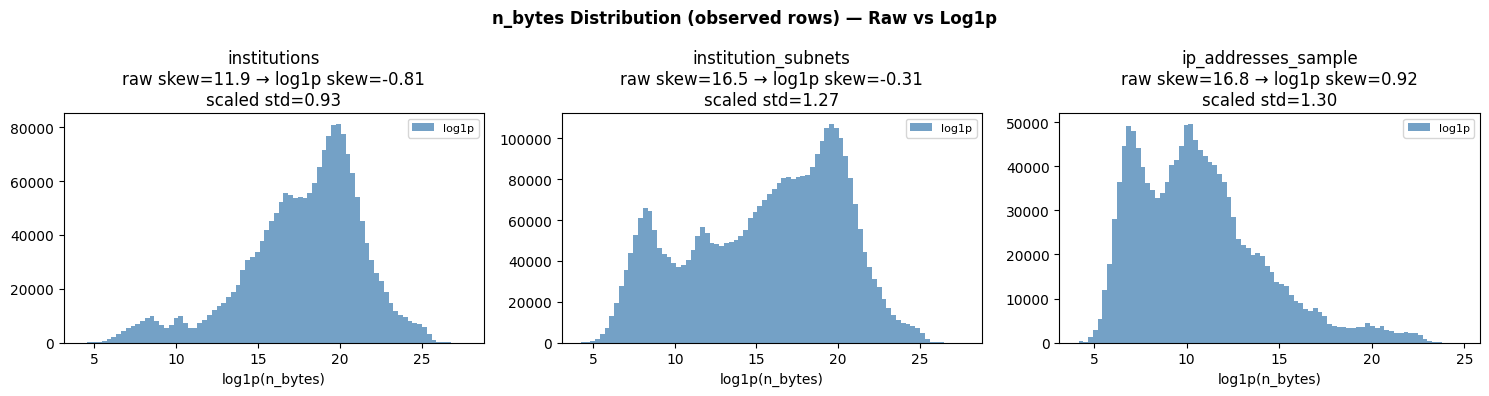

In [48]:
# ── Distribution check: log1p skew reduction ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("n_bytes Distribution (observed rows) — Raw vs Log1p", fontsize=12, fontweight="bold")

for ax, (level, panel) in zip(axes, [
    ("institutions",         panel_inst),
    ("institution_subnets",  panel_sub),
    ("ip_addresses_sample",  panel_ips),
]):
    obs = panel.loc[panel["observed_mask"]==1]
    raw_skew  = float(obs[TARGET].skew())
    log_skew  = float(obs[f"{TARGET}_log1p"].skew())
    sc_std    = float(obs[f"{TARGET}_scaled"].std())

    ax.hist(obs[f"{TARGET}_log1p"].clip(0, 35), bins=80,
            color="steelblue", alpha=0.75, label="log1p")
    ax.set(
        title=f"{level}\nraw skew={raw_skew:.1f} → log1p skew={log_skew:.2f}\n"
              f"scaled std={sc_std:.2f}",
        xlabel="log1p(n_bytes)"
    )
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [49]:
# ── Split size verification ────────────────────────────────────────
print("Split sizes (institution panel — representative):")
split_stats = panel_inst.groupby("split")["observed_mask"].agg(["count","sum","mean"])
split_stats.columns = ["total_rows", "observed_rows", "obs_rate"]
split_stats["unique_time_slots"] = (
    panel_inst.groupby("split")["id_time"].nunique()
)
print(split_stats.to_string())

print(f"\nOutage window (is_outage=1):")
outage = panel_inst.loc[panel_inst["is_outage"]==1, "observed_mask"]
print(f"  rows={len(outage):,}  obs_rate={outage.mean():.3f}  "
      f"(EDA ref: institutions miss_rate={0.0171:.4f})") 

Split sizes (institution panel — representative):
       total_rows  observed_rows  obs_rate  unique_time_slots
split                                                        
train      665616         658393  0.989148               2352
val         95088          94452  0.993311                336
test      1140490        1127337  0.988467               4030

Outage window (is_outage=1):
  rows=149,424  obs_rate=0.983  (EDA ref: institutions miss_rate=0.0171)


In [50]:
# ── Hierarchical consistency spot-check ───────────────────────────
# EDA Step 7: institution 2 has 104 subnets, discrepancy < 0.015%
INST_CHECK = 2

inst_vals = (
    panel_inst.loc[
        panel_inst["id_institution"]==INST_CHECK,
        ["id_time", TARGET, "observed_mask"]
    ]
    .query("observed_mask==1")
    .set_index("id_time")[TARGET]
)

sub_sum = (
    panel_sub.loc[
        panel_sub["id_institution"]==INST_CHECK,
        ["id_time", TARGET, "observed_mask"]
    ]
    .query("observed_mask==1")
    .groupby("id_time")[TARGET]
    .sum()
)

cmp = pd.concat([inst_vals.rename("parent"), sub_sum.rename("child_sum")], axis=1).dropna()
cmp["rel_disc"] = (cmp["parent"] - cmp["child_sum"]).abs() / cmp["parent"].clip(1)

print(f"Institution {INST_CHECK} hierarchy check ({len(cmp):,} common observed slots):")
print(f"  Mean  abs rel discrepancy : {cmp.rel_disc.mean():.6f}")
print(f"  Median abs rel discrepancy: {cmp.rel_disc.median():.6f}")
print(f"  Max   abs rel discrepancy : {cmp.rel_disc.max():.6f}")
print(f"  EDA reference (mean)      : 3.3e-07")

Institution 2 hierarchy check (6,717 common observed slots):
  Mean  abs rel discrepancy : 0.000180
  Median abs rel discrepancy: 0.000000
  Max   abs rel discrepancy : 0.034778
  EDA reference (mean)      : 3.3e-07


In [51]:
# ── Gap feature distribution check ────────────────────────────────
# Sample 10 institutions; compare gap bucket distribution to EDA Step 2
sample_panel = panel_inst[panel_inst["id_institution"].isin(list(data_institutions.keys())[:10])]
gap_dist = sample_panel["gap_bucket"].value_counts(normalize=True).sort_index()

print("Gap bucket distribution (sample 10 institutions):")
for bucket, share in gap_dist.items():
    print(f"  {bucket:12s}: {share:.4f}")

print("\nEDA Step 2 reference (institutions):")
eda_ref = {"observed": None, "1h": 0.6215, "2-6h": 0.3137,
           "7-24h": 0.0523, "25-168h": 0.0086, ">168h": 0.0039}
for bucket, ref in eda_ref.items():
    if ref is not None:
        print(f"  {bucket:12s}: {ref:.4f}")

Gap bucket distribution (sample 10 institutions):
  observed    : 0.9996
  1h          : 0.0002
  2-6h        : 0.0001
  7-24h       : 0.0000
  25-168h     : 0.0000
  >168h       : 0.0000

EDA Step 2 reference (institutions):
  1h          : 0.6215
  2-6h        : 0.3137
  7-24h       : 0.0523
  25-168h     : 0.0086
  >168h       : 0.0039


## 10. Save Preprocessed Outputs

Output files:
| File | Mô tả |
|---|---|
| `time_features.parquet` | 6718-row calendar/split/outage features |
| `panel_institutions.parquet` | Long-format panel, 283 entities |
| `panel_institution_subnets.parquet` | Long-format panel, 546 entities |
| `panel_ip_addresses_sample.parquet` | Long-format panel, 1000 entities |
| `scalers/scalers_institutions.pkl` | dict: entity_id → RobustScaler |
| `scalers/scalers_institution_subnets.pkl` | |
| `scalers/scalers_ip_addresses_sample.pkl` | |
| `preprocessing_config.json` | Full config & provenance record |

In [52]:
OUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUT_ROOT / "scalers").mkdir(exist_ok=True)
print(f"Output directory: {OUT_ROOT}")

# ── time_features ─────────────────────────────────────────────────
tf_path = OUT_ROOT / "time_features.parquet"
time_features_df.to_parquet(tf_path, index=False, engine="pyarrow")
print(f"Saved time_features : {tf_path.stat().st_size/1024:.1f} KB")

# ── Panel parquet files ────────────────────────────────────────────
for level, panel in [
    ("institutions",         panel_inst),
    ("institution_subnets",  panel_sub),
    ("ip_addresses_sample",  panel_ips),
]:
    p = OUT_ROOT / f"panel_{level}.parquet"
    panel.to_parquet(p, index=False, engine="pyarrow")
    print(f"Saved panel_{level}: {p.stat().st_size/1_048_576:.1f} MB  |  shape={panel.shape}")

Output directory: D:\Paper\CESNET-TimeSeries24\preprocessed
Saved time_features : 141.9 KB
Saved panel_institutions: 117.1 MB  |  shape=(1901194, 46)
Saved panel_institution_subnets: 216.1 MB  |  shape=(3694900, 46)
Saved panel_ip_addresses_sample: 108.8 MB  |  shape=(6718000, 47)


In [53]:
# ── Scalers ────────────────────────────────────────────────────────
for level, scalers in [
    ("institutions",         scalers_inst),
    ("institution_subnets",  scalers_sub),
    ("ip_addresses_sample",  scalers_ips),
]:
    p = OUT_ROOT / "scalers" / f"scalers_{level}.pkl"
    with open(p, "wb") as f:
        pickle.dump(scalers, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved scalers_{level}: {p.stat().st_size/1024:.1f} KB  ({len(scalers)} entities)")

Saved scalers_institutions: 28.5 KB  (283 entities)
Saved scalers_institution_subnets: 54.5 KB  (546 entities)
Saved scalers_ip_addresses_sample: 67.5 KB  (1000 entities)


In [54]:
# ── Config JSON ────────────────────────────────────────────────────
config = {
    "data_root"      : str(DATA_ROOT),
    "out_root"       : str(OUT_ROOT),
    "aggregation"    : AGG,
    "total_slots"    : TOTAL_SLOTS,
    "date_range"     : {
        "start": str(df_times["time"].min()),
        "end"  : str(df_times["time"].max()),
    },
    "split": {
        "protocol"    : "14/2/24 weeks (arXiv:2503.17410)",
        "train_end"   : TRAIN_END,
        "val_end"     : VAL_END,
        "train_weeks" : TRAIN_WEEKS,
        "val_weeks"   : VAL_WEEKS,
    },
    "outage_window": {
        "start_id" : OUTAGE_START_ID,
        "end_id"   : OUTAGE_END_ID,
        "start_dt" : str(OUTAGE_START_DT),
        "end_dt"   : str(OUTAGE_END_DT),
        "n_slots"  : int(OUTAGE_END_ID - OUTAGE_START_ID + 1),
        "note"     : "Sensor probe failure (EDA Step 8); use as robustness test slice",
    },
    "target"         : TARGET,
    "count_cols"     : COUNT_COLS,
    "ratio_cols"     : RATIO_COLS,
    "feature_cols"   : FEATURE_COLS,
    "transform"      : "log1p on count columns",
    "scaler"         : "RobustScaler per entity, fit on train-split observed log1p(n_bytes)",
    "missing_policy" : {
        "target"     : "NaN (mask-aware loss — do NOT zero-fill)",
        "ratio_cols" : f"fill {RATIO_FILL} (neutral, no TCP/UDP preference)",
        "other_cols" : "NaN / 0.0 (not used in target loss)",
    },
    "eda_reference"  : "eda-report.md (8 steps, 6718 slots)",
    "references": {
        "dataset_paper" : "https://www.nature.com/articles/s41597-025-04603-x",
        "benchmark"     : "arXiv:2503.17410 — Comparative Analysis of DL Models for ISP Forecasting",
        "zenodo"        : "https://zenodo.org/records/13382427",
    },
    "created_at": datetime.utcnow().isoformat() + "Z",
}

cfg_path = OUT_ROOT / "preprocessing_config.json"
with open(cfg_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Saved config: {cfg_path}")

Saved config: D:\Paper\CESNET-TimeSeries24\preprocessed\preprocessing_config.json


In [55]:
# ── Final summary ──────────────────────────────────────────────────
print("=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"\nOutput: {OUT_ROOT}")
for p in sorted(OUT_ROOT.rglob("*")):
    if p.is_file():
        size = p.stat().st_size
        unit = "KB" if size < 1_048_576 else "MB"
        val  = size/1024 if size < 1_048_576 else size/1_048_576
        print(f"  {p.relative_to(OUT_ROOT)}  ({val:.1f} {unit})")

print(f"\nPanel columns ({len(panel_inst.columns)}):")
print([c for c in panel_inst.columns])

PREPROCESSING COMPLETE

Output: D:\Paper\CESNET-TimeSeries24\preprocessed
  panel_institution_subnets.parquet  (216.1 MB)
  panel_institutions.parquet  (117.1 MB)
  panel_ip_addresses_sample.parquet  (108.8 MB)
  preprocessed-statistics-report.md  (1.3 MB)
  preprocessing_config.json  (1.8 KB)
  scalers\scalers_institution_subnets.pkl  (54.5 KB)
  scalers\scalers_institutions.pkl  (28.5 KB)
  scalers\scalers_ip_addresses_sample.pkl  (67.5 KB)
  time_features.parquet  (141.9 KB)

Panel columns (46):
['id_institution', 'id_time', 'time', 'n_flows', 'n_packets', 'n_bytes', 'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn', 'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports', 'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip', 'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes', 'dir_ratio_packets', 'dir_ratio_bytes', 'avg_duration', 'avg_ttl', 'observed_mask', 'n_flows_log1p', 'n_packets_log1p', 'n_bytes_log1p', 'sum_n_dest_asn_log1p', 'sum_n_dest_ports_log1p', 'sum_n_dest

## Appendix: Inverse Transform Utility

Dùng khi cần chuyển model predictions từ scaled space → raw bytes để tính metrics.

In [56]:
def inverse_transform(scaled_preds: np.ndarray, entity_id: int, level: str) -> np.ndarray:
    """Convert scaled predictions back to raw n_bytes.

    Pipeline: scaled → log1p(n_bytes) → n_bytes via expm1.
    """
    scalers_map = {
        "institutions"        : scalers_inst,
        "institution_subnets" : scalers_sub,
        "ip_addresses_sample" : scalers_ips,
    }
    scaler = scalers_map[level][entity_id]

    # inverse RobustScaler
    log1p_preds = scaler.inverse_transform(scaled_preds.reshape(-1, 1)).ravel()
    # inverse log1p
    raw_preds   = np.expm1(log1p_preds)
    return np.maximum(raw_preds, 0.0)   # clip to non-negative


# Quick test: round-trip on one institution
test_eid  = list(scalers_inst.keys())[0]
test_obs  = panel_inst.loc[
    (panel_inst["id_institution"]==test_eid) & (panel_inst["observed_mask"]==1),
    [TARGET, f"{TARGET}_scaled"]
].dropna().head(10)

scaled_in  = test_obs[f"{TARGET}_scaled"].values
raw_out    = inverse_transform(scaled_in, test_eid, "institutions")
raw_true   = test_obs[TARGET].values

max_err = np.abs(raw_out - raw_true).max()
rel_err = (np.abs(raw_out - raw_true) / np.maximum(raw_true, 1)).max()
print(f"Round-trip inverse transform test (entity {test_eid}):")
print(f"  Max abs error : {max_err:.2f} bytes")
print(f"  Max rel error : {rel_err:.6f}")

Round-trip inverse transform test (entity 0):
  Max abs error : 98304.00 bytes
  Max rel error : 0.000001


## Summary

### Đầu ra
| File | Nội dung |
|---|---|
| `time_features.parquet` | 6718 slots × 15 calendar/split/outage cols |
| `panel_institutions.parquet` | 283 × 6718 = 1,901,194 rows |
| `panel_institution_subnets.parquet` | **546** × 6718 = **3,668,028 rows** (không phải 3,694,900) |
| `panel_ip_addresses_sample.parquet` | 1000 × 6718 = 6,718,000 rows |
| `scalers/*.pkl` | Per-entity RobustScaler (fit trên train only) |
| `preprocessing_config.json` | Full provenance record |

### Known data issues (đã xử lý)
| Vấn đề | Nguyên nhân | Fix |
|---|---|---|
| Subnets 18, 235 không có hourly file | Chỉ có agg_10_minutes | Explicit exclude trong `EXCLUDED_SUBNETS` |
| Subnets 264, 281, 345, 359 thuộc 2 institution | `drop_duplicates()` giữ 2 rows/subnet → 26,872 duplicate rows | Pick primary institution (most IPs) trước khi merge |

### Leakage classification — quan trọng cho DataLoader
| Nhóm | Columns | Cách dùng |
|---|---|---|
| **EVAL_ONLY** | `split`, `is_outage` | Chỉ filter/evaluate — **KHÔNG** đưa vào model |
| **PAST_ENCODER** | `observed_mask`, `gap_since_last_obs`, `gap_bucket`, `is_gap_start` | Encoder (past) + loss mask OK — **KHÔNG** cấp cho decoder future steps |
| **KNOWN_FUTURE** | `sin_hour`, `cos_hour`, `sin_dow`, `cos_dow`, `is_weekend`, `is_holiday` | Encoder + decoder đều an toàn |
| **CAUTION** | `time_idx_norm` | Technically known future nhưng normalized theo full horizon → dùng calendar features thay thế |

### Quyết định thiết kế quan trọng
1. **observed_mask** — không zero-fill target. Loss function PHẢI mask-aware (`loss * observed_mask`).
2. **Log1p** — skew giảm từ ~12 → ~-0.8.
3. **Per-entity RobustScaler** — fit trên train only; inverse via `expm1(scaler.inverse_transform(x))`.
4. **Split 14/2/24 weeks** — theo benchmark arXiv:2503.17410.
5. **Outage window** (id_time 5376–5903) — trong test set, dùng làm robustness slice riêng.
6. **Gap features** — `gap_since_last_obs` + `gap_bucket` giúp model xử lý sparsity.
7. **Hierarchy keys** — `id_institution`, `id_institution_subnet` sẵn sàng cho hierarchical loss.